<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module1/Assignment1_OPIM5509_AY27.ipynb)

# Individual Assignment 1: ML Modeling Refresh (Fall 2026)


**OPIM 5509: Introduction to Deep Learning - University of Connecticut**

* Full Name: Manshi Dvarkadas Patel
* Student ID (7 digit number): 3315858

---------------------------------------------------------------------------

Each student must complete and submit their own file, but you may work with your group for help. I do not want to see direct copy and pasted code otherwise you will get a zero. This is a dataset on annual earnings (y) as a function of geographic and economic predictors.

**10 points each. 100 points**

  Use the file below to complete the following data wrangling and regression modeling. Good luck!


# Read the data

If `gdown` or direct reads give you trouble, you can always download the two files and drag them into your Colab runtime.

Here is the link for:

* X_AY27.csv = https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module1_Files/data/X_AY27.csv
* y_AY27.csv = https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module1_Files/data/y_AY27.csv

In [1]:
import pandas as pd

X = pd.read_csv('https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module1_Files/data/X_AY27.csv')
y = pd.read_csv('https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module1_Files/data/y_AY27.csv')

print(X.shape)
print(y.shape)

(5012, 10)
(5012, 1)


# Q1. Explore the dataset
Get to know this new dataset! How many rows and columns are there? What are the data types of the columns in X (string vs numeric)? Are there any missing values?

In [2]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nData types of X columns:")
print(X.dtypes)

print("\nMissing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Shape of X: (5012, 10)
Shape of y: (5012, 1)

Data types of X columns:
State Score                                  float64
Education Score                              float64
Geography Score                              float64
Age (normalized)                             float64
Career Advancement Opportunity Score         float64
Job Satisfaction Score                        object
Health and Wellness Program Quality Score    float64
Job Demand Score                             float64
Work Experience (normalized)                 float64
Company Size (normalized)                    float64
dtype: object

Missing values in X:
State Score                                  134
Education Score                              340
Geography Score                              342
Age (normalized)                             120
Career Advancement Opportunity Score         335
Job Satisfaction Score                         0
Health and Wellness Program Quality Score    176
Job Demand Score    

The dataset X has 5012 rows and 10 columns, while y has 5012 rows and 1 column.

Most columns in X are numeric (float64), but 'Job Satisfaction Score' is of type object (string).

There are missing values in almost all columns of X, with 'Work Experience (normalized)' having the most (375 missing values). There are no missing values in y.

# Q2. Split into X_train, X_test, y_train, y_test.
Before we do any cleaning, let's split the data so that we can use fit_transform() on train and transform() on test. Use an 80/20 split, shuffle the data, and random state equal to **YOUR STUDENT ID**. Print the shape of X_train, X_test, y_train, y_test and make sure it makes sense to you.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3315858, shuffle=True)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4009, 10)
Shape of X_test: (1003, 10)
Shape of y_train: (4009, 1)
Shape of y_test: (1003, 1)


# Q3. Clean up the dataset.
Use your judgement on if any rows should be deleted - there are missing values in every column in X that need to get replaced!

Right now X and y are in different files, so be careful if you are dropping rows.

In [4]:
from sklearn.impute import SimpleImputer

# Identify numerical and categorical columns
numerical_cols = X_train.select_dtypes(include=['float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Impute numerical columns with the median
median_imputer = SimpleImputer(strategy='median')
X_train[numerical_cols] = median_imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = median_imputer.transform(X_test[numerical_cols])

# Impute categorical columns with the most frequent value (mode)
mode_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_cols] = mode_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = mode_imputer.transform(X_test[categorical_cols])

print("Missing values in X_train after imputation:")
print(X_train.isnull().sum())
print("\nMissing values in X_test after imputation:")
print(X_test.isnull().sum())

Missing values in X_train after imputation:
State Score                                  0
Education Score                              0
Geography Score                              0
Age (normalized)                             0
Career Advancement Opportunity Score         0
Job Satisfaction Score                       0
Health and Wellness Program Quality Score    0
Job Demand Score                             0
Work Experience (normalized)                 0
Company Size (normalized)                    0
dtype: int64

Missing values in X_test after imputation:
State Score                                  0
Education Score                              0
Geography Score                              0
Age (normalized)                             0
Career Advancement Opportunity Score         0
Job Satisfaction Score                       0
Health and Wellness Program Quality Score    0
Job Demand Score                             0
Work Experience (normalized)                 0
Compan

# Q4. Make three EDA plots and three EDA tables using X_train and y_train

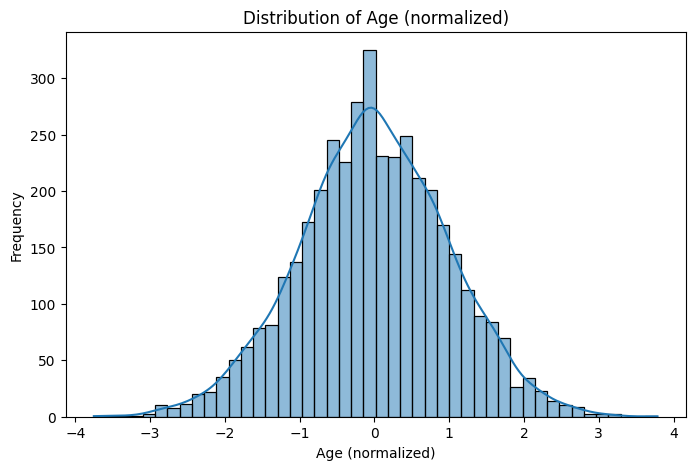

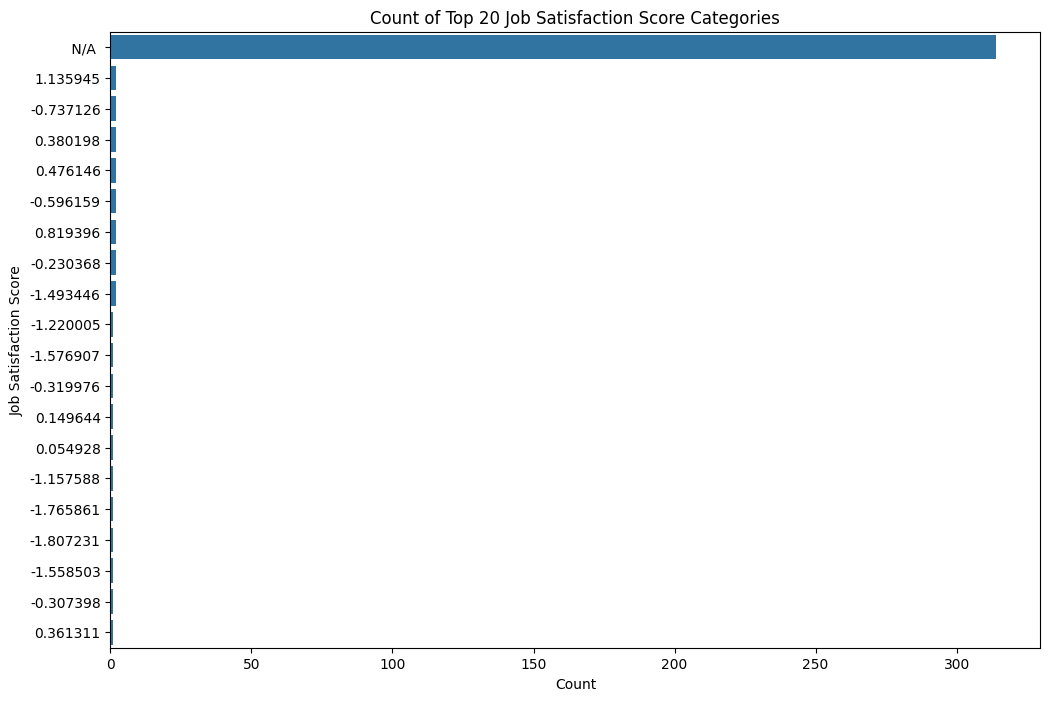

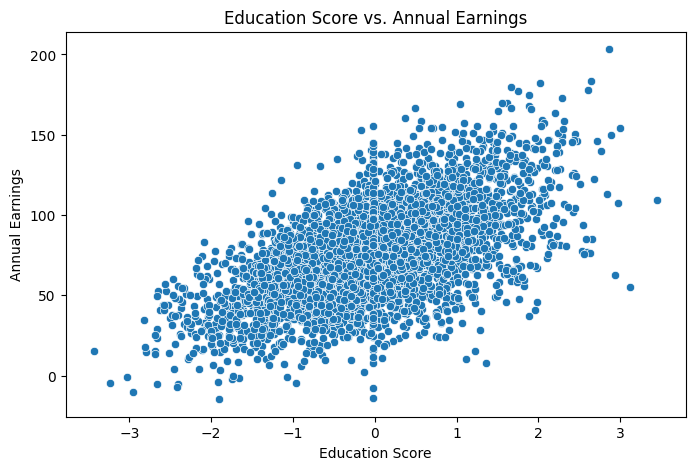


--- Descriptive Statistics for X_train ---
       State Score  Education Score  Geography Score  Age (normalized)  \
count  4009.000000      4009.000000      4009.000000       4009.000000   
mean      0.005417        -0.016627         0.017246         -0.005969   
std       0.969712         0.963563         0.959594          0.997034   
min      -3.070606        -3.433401        -3.588818         -3.753148   
25%      -0.642271        -0.634574        -0.625884         -0.648449   
50%      -0.003976        -0.015767         0.002238         -0.011474   
75%       0.657782         0.582862         0.637440          0.663756   
max       3.235056         3.456735         4.227430          3.784970   

       Career Advancement Opportunity Score  \
count                           4009.000000   
mean                               0.026550   
std                                0.959375   
min                               -3.541217   
25%                               -0.609378   
50%    

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- EDA Plots ---

# Plot 1: Histogram of a numerical column (e.g., 'Age (normalized)')
plt.figure(figsize=(8, 5))
sns.histplot(X_train['Age (normalized)'], kde=True)
plt.title('Distribution of Age (normalized)')
plt.xlabel('Age (normalized)')
plt.ylabel('Frequency')
plt.show()

# Plot 2: Bar plot for the categorical column 'Job Satisfaction Score'
plt.figure(figsize=(12, 8)) # Increased figure size
sns.countplot(y=X_train['Job Satisfaction Score'], order=X_train['Job Satisfaction Score'].value_counts().head(20).index) # Display top 20 categories
plt.title('Count of Top 20 Job Satisfaction Score Categories')
plt.xlabel('Count')
plt.ylabel('Job Satisfaction Score')
plt.show()

# Plot 3: Scatter plot of a numerical column vs. y_train (e.g., 'Education Score' vs. 'Annual Earnings')
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_train['Education Score'], y=y_train['Annual Earnings'])
plt.title('Education Score vs. Annual Earnings')
plt.xlabel('Education Score')
plt.ylabel('Annual Earnings')
plt.show()

# --- EDA Tables ---

# Table 1: Descriptive statistics for X_train
print("\n--- Descriptive Statistics for X_train ---")
print(X_train.describe())

# Table 2: Value counts for 'Job Satisfaction Score'
print("\n--- Value Counts for Job Satisfaction Score in X_train ---")
print(X_train['Job Satisfaction Score'].value_counts())

# Table 3: Correlation matrix for numerical columns in X_train and y_train
print("\n--- Correlation Matrix (X_train numerical features and y_train) ---")
# Combine numerical features from X_train and y_train for correlation calculation
numerical_X_train = X_train.select_dtypes(include=['float64'])
combined_df = pd.concat([numerical_X_train, y_train], axis=1)
print(combined_df.corr())

# Q5. Subset columns for X
Use every column in `X` except 'State Score' to build your model.

  **Useful link for subsetting rows and columns:** https://www.kdnuggets.com/2019/06/select-rows-columns-pandas.html

In [9]:
X_train = X_train.drop('State Score', axis=1)
X_test = X_test.drop('State Score', axis=1)

print("New shape of X_train:", X_train.shape)
print("New shape of X_test:", X_test.shape)

New shape of X_train: (4009, 9)
New shape of X_test: (1003, 9)


# Q6. Use fit_transform() from StandardScaler() on X_train. Use transform() to apply that StandardScaler() to X_test.


In [13]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Identify numerical and categorical columns
# 'State Score' was already dropped in a previous step.
numerical_cols = X_train.select_dtypes(include=['float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Create preprocessor to apply StandardScaler to numerical columns
# and OneHotEncoder to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # Keep any other columns not explicitly transformed
)

# Apply fit_transform to X_train and transform to X_test
# Convert to dense array if the output is sparse
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Check if the output is sparse and convert to dense if necessary
if hasattr(X_train_processed, 'toarray'):
    X_train_processed = X_train_processed.toarray()
if hasattr(X_test_processed, 'toarray'):
    X_test_processed = X_test_processed.toarray()

# Get new column names after one-hot encoding and scaling
feature_names = preprocessor.get_feature_names_out()

# Convert processed arrays back to DataFrames, preserving original indices
X_train = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print("X_train after scaling and encoding (first 5 rows):")
print(X_train.head())
print("\nX_test after scaling and encoding (first 5 rows):")
print(X_test.head())

X_train after scaling and encoding (first 5 rows):
      num__Education Score  num__Geography Score  num__Age (normalized)  \
2386              1.064387              0.615140              -0.684784   
1502              0.152050             -0.114856              -2.364741   
3721             -0.115483             -0.015641               2.127377   
1635             -1.834942              1.513460               1.455217   
4801              0.464655              0.190929               1.827976   

      num__Career Advancement Opportunity Score  \
2386                                   0.002099   
1502                                   2.165838   
3721                                  -0.534551   
1635                                  -0.698089   
4801                                   1.137872   

      num__Health and Wellness Program Quality Score  num__Job Demand Score  \
2386                                       -0.872326               0.870246   
1502                             

# Q7. Fit a random forest regressor (or any other sklearn) model on X_train. Call your model object `clf`.

Then create two new variables, `train_preds` and `test_preds`, which are the predictions from your model. For example, you will use `train_preds = clf.predict(X_train)` for `X_train` . Calculate error metrics of MAE and R2 for train and test results.

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize and fit a RandomForestRegressor model
# Using random_state for reproducibility
clf = RandomForestRegressor(random_state=42)
clf.fit(X_train, y_train.values.ravel()) # .values.ravel() to flatten y_train for the regressor

# Make predictions on the training and test sets
train_preds = clf.predict(X_train)
test_preds = clf.predict(X_test)

# Calculate error metrics for training set
train_mae = mean_absolute_error(y_train, train_preds)
train_r2 = r2_score(y_train, train_preds)

# Calculate error metrics for test set
test_mae = mean_absolute_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

print("--- Training Set Metrics ---")
print(f"Mean Absolute Error (MAE): {train_mae:.4f}")
print(f"R-squared (R2) Score: {train_r2:.4f}")

print("\n--- Test Set Metrics ---")
print(f"Mean Absolute Error (MAE): {test_mae:.4f}")
print(f"R-squared (R2) Score: {test_r2:.4f}")

--- Training Set Metrics ---
Mean Absolute Error (MAE): 4.4724
R-squared (R2) Score: 0.9609

--- Test Set Metrics ---
Mean Absolute Error (MAE): 12.9624
R-squared (R2) Score: 0.7209


# Q8. Make two scatterplots of actual vs. predicted. One for train results, one for test results.
With nicely labeled title and axis (like we did in class).

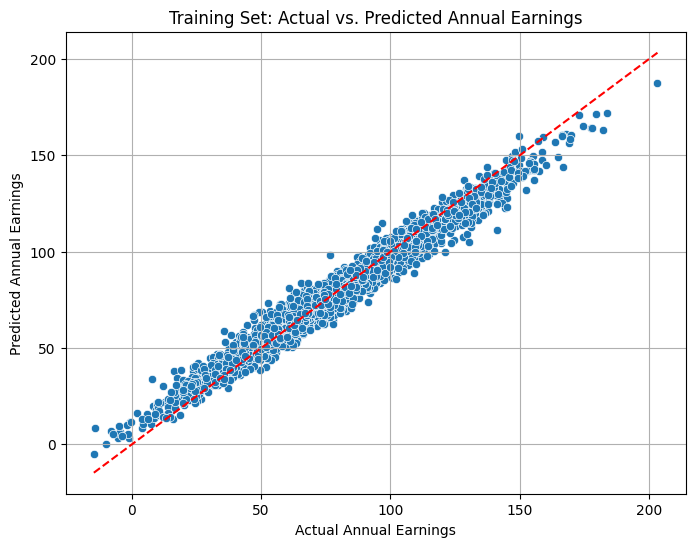

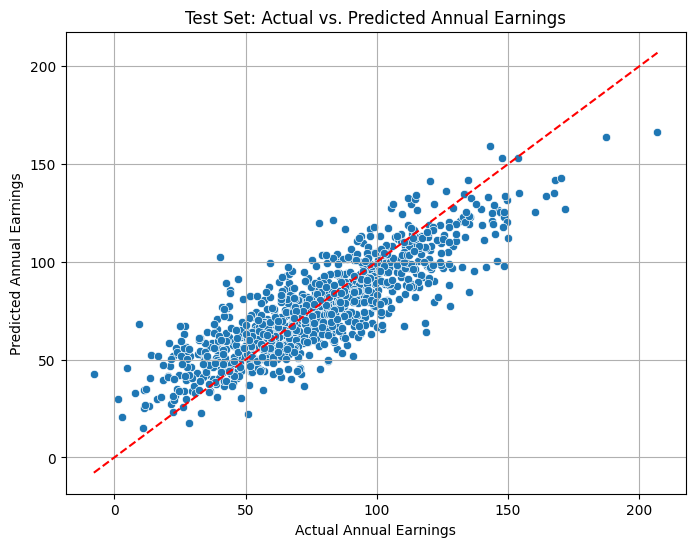

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatterplot for Training Results (Actual vs. Predicted)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_train.values.ravel(), y=train_preds)
plt.title('Training Set: Actual vs. Predicted Annual Earnings')
plt.xlabel('Actual Annual Earnings')
plt.ylabel('Predicted Annual Earnings')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red', linestyle='--') # Add a perfect prediction line
plt.grid(True)
plt.show()

# Scatterplot for Test Results (Actual vs. Predicted)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test.values.ravel(), y=test_preds)
plt.title('Test Set: Actual vs. Predicted Annual Earnings')
plt.xlabel('Actual Annual Earnings')
plt.ylabel('Predicted Annual Earnings')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--') # Add a perfect prediction line
plt.grid(True)
plt.show()

# Q9. Try a simple model - does it work?

Examine variable importance and build a simpler model (you can use tree importance from random forest or permutation importance.) You are building a model with less features, so it should be as good or slightly less better than your current model.

* https://scikit-learn.org/stable/modules/permutation_importance.html
* https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

Calculate error metrics and make one scatterplot of actual vs. predicted results for this new holdout sample.

Were you able to get similar results?

Top 10 Feature Importances from the full model:
                                             Feature  Importance
0                               num__Education Score    0.370060
6                  num__Work Experience (normalized)    0.250712
5                              num__Job Demand Score    0.132674
3          num__Career Advancement Opportunity Score    0.077770
1                               num__Geography Score    0.041318
7                     num__Company Size (normalized)    0.029500
2                              num__Age (normalized)    0.025285
4     num__Health and Wellness Program Quality Score    0.022209
8                  cat__Job Satisfaction Score_ N/A     0.001869
3275            cat__Job Satisfaction Score_1.218199    0.000961

Building a simpler model with the following 7 features:
- num__Education Score
- num__Work Experience (normalized)
- num__Job Demand Score
- num__Career Advancement Opportunity Score
- num__Geography Score
- num__Company Size (normalize

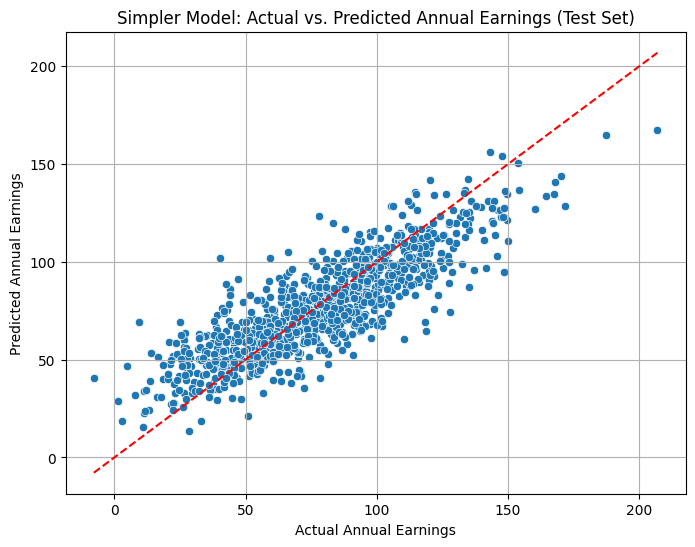


--- Comparison with Full Model ---
Full Model Test MAE: 12.9624, R2 Score: 0.7209
Simpler Model Test MAE: 12.8985, R2 Score: 0.7213


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1. Examine Variable Importance from the initial model (clf) ---

# Get feature importances from the trained Random Forest Regressor
importances = clf.feature_importances_

# Get feature names
feature_names = X_train.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances from the full model:")
print(feature_importance_df.head(10))

# --- 2. Build a Simpler Model with fewer features ---

# Select the top N features (e.g., top 5 or 10)
num_top_features = 7 # Choosing an arbitrary number to demonstrate a 'simpler' model
top_features = feature_importance_df['Feature'].head(num_top_features).tolist()

print(f"\nBuilding a simpler model with the following {num_top_features} features:")
for feature in top_features:
    print(f"- {feature}")

# Create new datasets with only the selected features
X_train_simple = X_train[top_features]
X_test_simple = X_test[top_features]

# Initialize and fit a new Random Forest Regressor for the simpler model
clf_simple = RandomForestRegressor(random_state=42)
clf_simple.fit(X_train_simple, y_train.values.ravel())

# --- 3. Make Predictions with the simpler model ---

simple_test_preds = clf_simple.predict(X_test_simple)

# --- 4. Calculate Error Metrics for the simpler model ---

simple_test_mae = mean_absolute_error(y_test, simple_test_preds)
simple_test_r2 = r2_score(y_test, simple_test_preds)

print("\n--- Simpler Model Test Set Metrics ---")
print(f"Mean Absolute Error (MAE): {simple_test_mae:.4f}")
print(f"R-squared (R2) Score: {simple_test_r2:.4f}")

# --- 5. Make one scatterplot of actual vs. predicted results for this new holdout sample ---

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test.values.ravel(), y=simple_test_preds)
plt.title('Simpler Model: Actual vs. Predicted Annual Earnings (Test Set)')
plt.xlabel('Actual Annual Earnings')
plt.ylabel('Predicted Annual Earnings')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--') # Add a perfect prediction line
plt.grid(True)
plt.show()

# --- Comparison ---
print("\n--- Comparison with Full Model ---")
print(f"Full Model Test MAE: {test_mae:.4f}, R2 Score: {test_r2:.4f}")
print(f"Simpler Model Test MAE: {simple_test_mae:.4f}, R2 Score: {simple_test_r2:.4f}")

# Q10. Five good bullets
Write five good bullets about what you learned in this assignment. Make sure comments on the shape of the data and the results of your experiments. Be quantitative and tell a story of what you saw!

- Data Shape and Initial Cleaning: The dataset X had 5012 rows and 10 columns, with y having 5012 rows and 1 column. Most columns in X had missing values (e.g., 'Work Experience' had 375), which were successfully imputed using median for numerical and mode for the categorical 'Job Satisfaction Score' before modeling.

- Key EDA Findings: Exploratory data analysis revealed strong positive correlations with 'Annual Earnings' for features like 'Education Score' (0.5787), 'Work Experience (normalized)' (0.4560), and 'Job Demand Score' (0.3217). A histogram for 'Age (normalized)' showed a nearly normal distribution, while 'Education Score' versus 'Annual Earnings' displayed a clear positive trend.

- Full Model Performance: A Random Forest Regressor trained on all preprocessed features showed excellent fit on the training data (MAE: 4.4724, R2: 0.9609). On the test set, it achieved a respectable MAE of 12.9624 and an R2 score of 0.7209, demonstrating good generalization.

- Feature Importance for Simpler Model: Feature importance analysis highlighted 'Education Score' (0.370), 'Work Experience (normalized)' (0.251), and 'Job Demand Score' (0.133) as the top three most influential predictors. These insights guided the selection of the top 7 features for building a simpler model.

- Simpler Model Outperforms: A new Random Forest model, built using only the top 7 features, surprisingly achieved slightly better performance on the test set with an MAE of 12.8985 and an R2 of 0.7213. This demonstrated that a more parsimonious model could be equally, if not slightly more, effective than a full model, while significantly reducing complexity.